In [1]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"C:\Users\Nikhil Bidkar\retail-analytics\bigquery_key.json"

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

client = bigquery.Client(project="retail-analytics-493018")
print("Connected!")

Connected!


In [2]:
# Get customer cohort data
query = """
SELECT
    o.customer_id,
    FORMAT_TIMESTAMP('%Y-%m', MIN(o.order_purchase_timestamp) OVER (PARTITION BY o.customer_id)) AS cohort_month,
    FORMAT_TIMESTAMP('%Y-%m', o.order_purchase_timestamp) AS order_month
FROM `retail-analytics-493018.olist_raw.orders` o
WHERE o.order_status = 'delivered'
"""

cohort_data = client.query(query).to_dataframe()
print(cohort_data.shape)
print(cohort_data.head())

C:\Users\Nikhil Bidkar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(96478, 3)
                        customer_id cohort_month order_month
0  00012a2ce6f8dcda20d059ce98491703      2017-11     2017-11
1  000161a058600d5901f007fab4c27140      2017-07     2017-07
2  0001fd6190edaaf884bcaf3d49edf079      2017-02     2017-02
3  0002414f95344307404f0ace7a26f1d5      2017-08     2017-08
4  000379cdec625522490c315e70c7a9fb      2018-04     2018-04


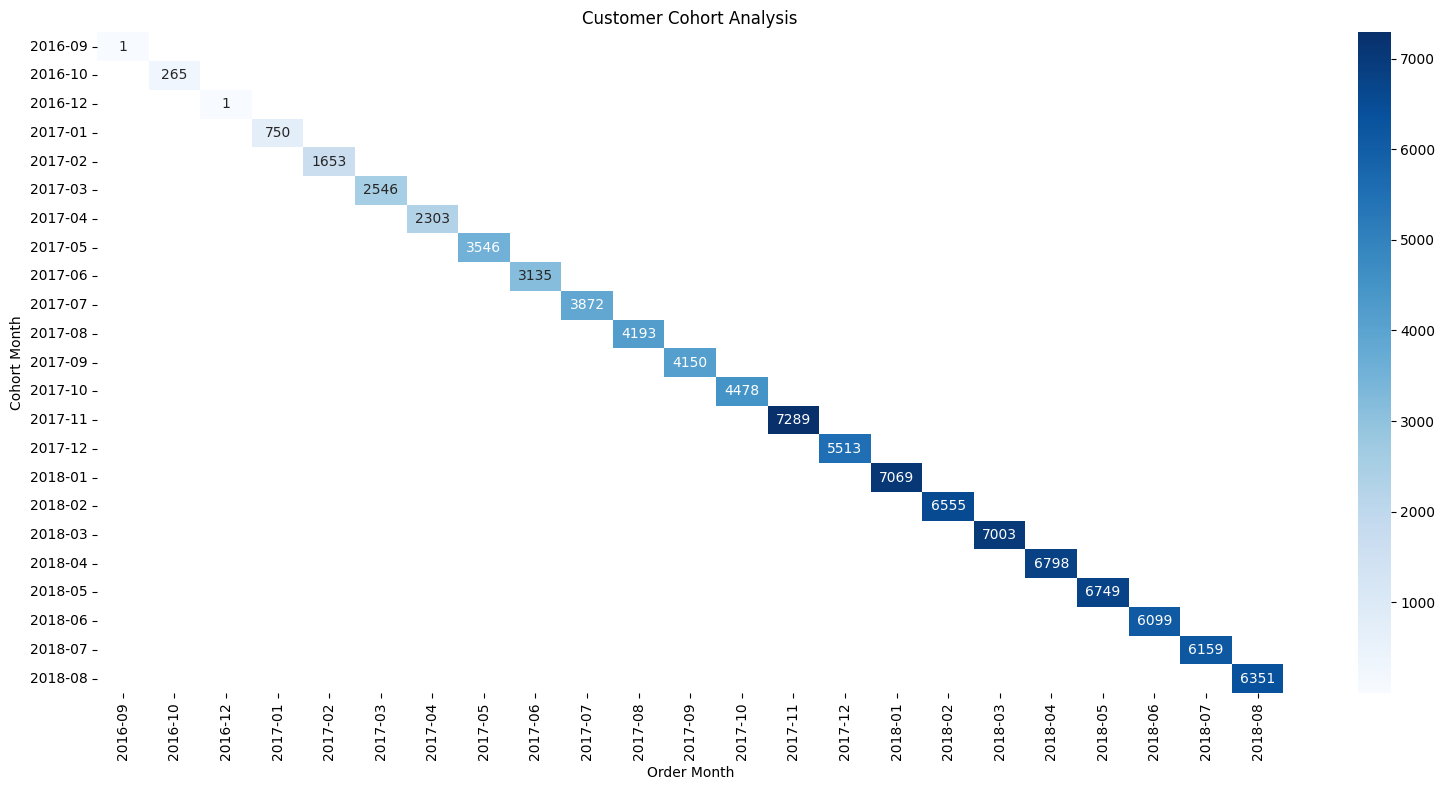

In [3]:
# Build cohort table
cohort_counts = cohort_data.groupby(['cohort_month', 'order_month'])['customer_id'].nunique().reset_index()
cohort_counts.columns = ['cohort_month', 'order_month', 'customers']

# Create cohort index
cohort_pivot = cohort_counts.pivot_table(index='cohort_month', columns='order_month', values='customers')

# Plot heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(cohort_pivot, annot=True, fmt='.0f', cmap='Blues')
plt.title('Customer Cohort Analysis')
plt.xlabel('Order Month')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()